#### CAPSTONE PROJECT

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot , quarter_plot,plot_acf, plot_pacf 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing , ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [2]:
df = pd.read_csv(r"C:\Users\manoj.c\Documents\PANDAS_PROJECT\Pandas-Project-6\Datasets\airmiles.csv",index_col="Date",parse_dates=True, dayfirst=True)
df.head()

,airmiles
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 113 entries, 1996-01-01 to 2005-05-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   airmiles  113 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


In [4]:
df.index

DatetimeIndex(['1996-01-01', '1996-02-01', '1996-03-01', '1996-04-01',
               '1996-05-01', '1996-06-01', '1996-07-01', '1996-08-01',
               '1996-09-01', '1996-10-01',
               ...
               '2004-08-01', '2004-09-01', '2004-10-01', '2004-11-01',
               '2004-12-01', '2005-01-01', '2005-02-01', '2005-03-01',
               '2005-04-01', '2005-05-01'],
              dtype='datetime64[ns]', name='Date', length=113, freq=None)

In [5]:
# Set start of the month date
df = df.asfreq("MS")
df.index

DatetimeIndex(['1996-01-01', '1996-02-01', '1996-03-01', '1996-04-01',
               '1996-05-01', '1996-06-01', '1996-07-01', '1996-08-01',
               '1996-09-01', '1996-10-01',
               ...
               '2004-08-01', '2004-09-01', '2004-10-01', '2004-11-01',
               '2004-12-01', '2005-01-01', '2005-02-01', '2005-03-01',
               '2005-04-01', '2005-05-01'],
              dtype='datetime64[ns]', name='Date', length=113, freq='MS')

In [6]:
# rename
df = df.rename(columns={'airmiles': 'Y'})

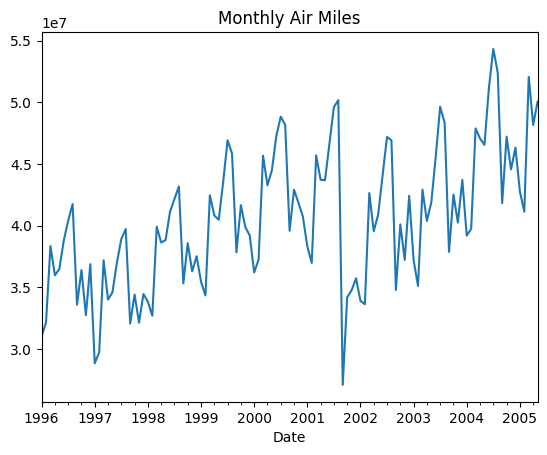

In [7]:
## Exploratory Data Analysis
df['Y'].plot(title="Monthly Air Miles")
plt.show()

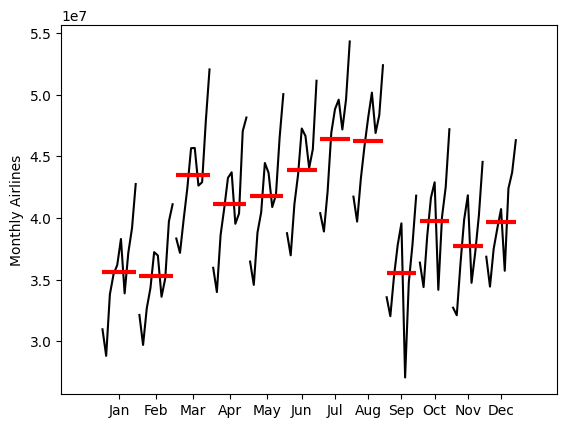

In [8]:
month_plot(df['Y'], ylabel = 'Monthly Airlines')
plt.show()

C:\Users\manoj.c\AppData\Local\Temp\ipykernel_12992\2584079907.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df['Y'].resample('Q').mean() ,ylabel='Quarterly Airmiles')


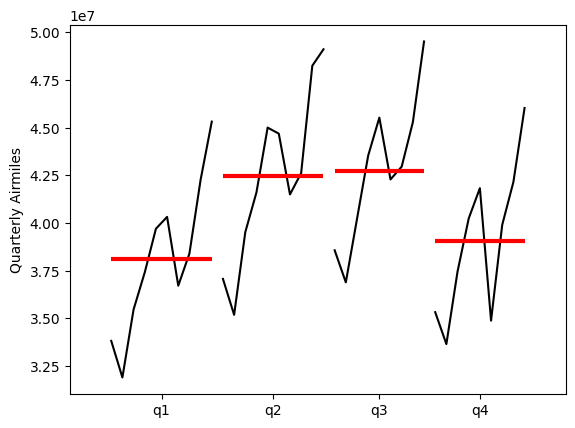

In [9]:
quarter_plot(df['Y'].resample('Q').mean() ,ylabel='Quarterly Airmiles')
plt.show()

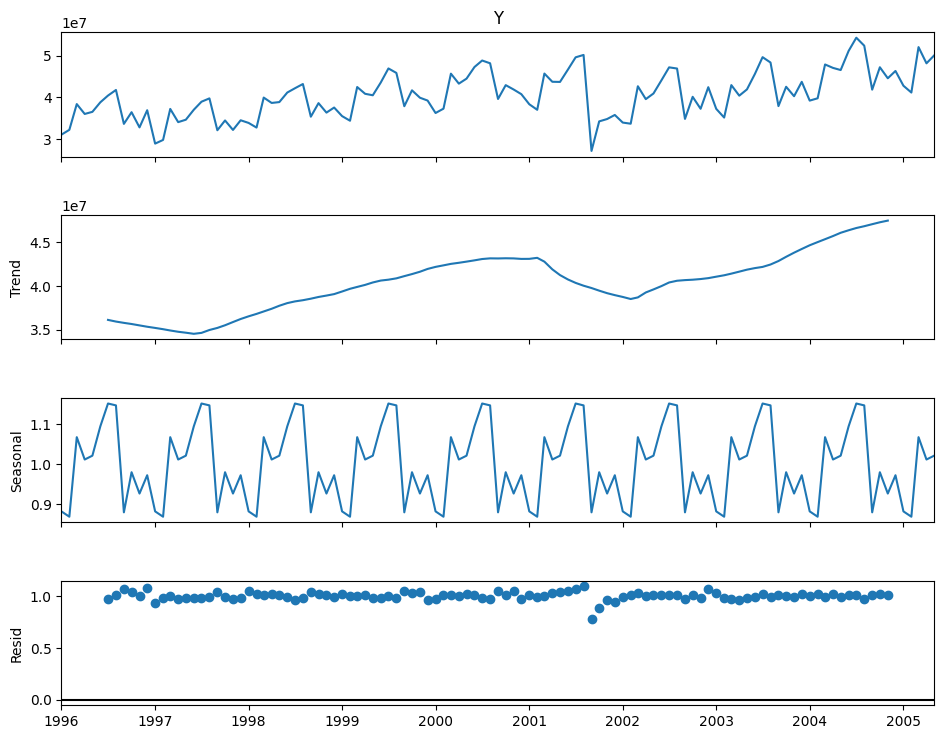

In [12]:
decomposition = seasonal_decompose(df['Y'], model = 'mul', period = 12)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

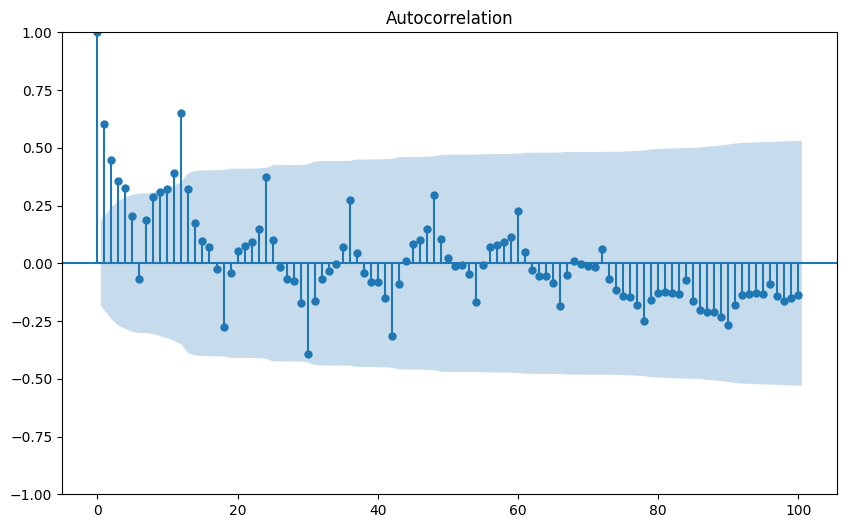

In [14]:
fig , ax = plt.subplots(figsize = (10,6))
plot_acf(df["Y"],lags=100, ax=ax)
plt.show()

In [16]:
df['Y']

Date
1996-01-01    30983174
1996-02-01    32147663
1996-03-01    38342975
1996-04-01    35969113
1996-05-01    36474391
                ...   
2005-01-01    42760657
2005-02-01    41120838
2005-03-01    52053059
2005-04-01    48152585
2005-05-01    50047901
Freq: MS, Name: Y, Length: 113, dtype: int64

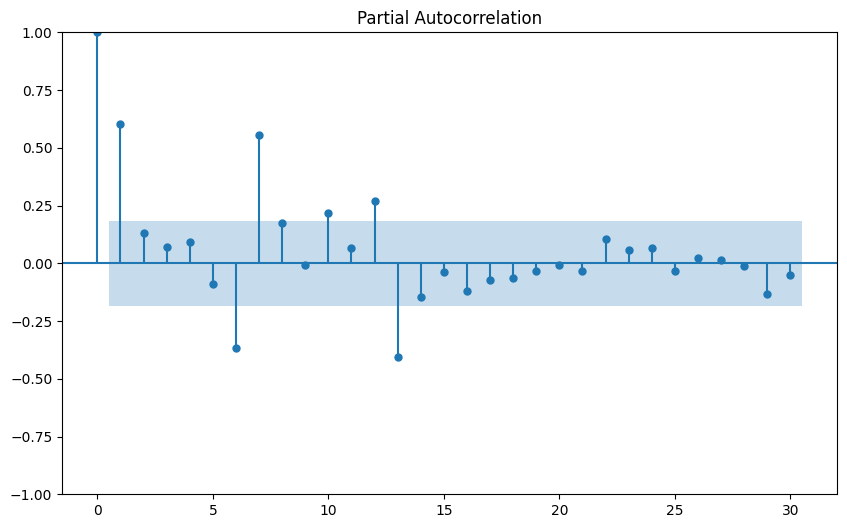

In [21]:
fig , ax = plt.subplots(figsize = (10,6))
plot_pacf(df['Y'],lags=30,ax=ax)
plt.show()

In [25]:
## Holt - Winters (Train & Test)
train, test = df.iloc[:-12,:] , df.iloc[-12: ,:] 
test

,Y
Date,
2004-06-01,51134050
2004-07-01,54317314
2004-08-01,52392985
2004-09-01,41816777
2004-10-01,47205665
2004-11-01,44553653
2004-12-01,46316602
2005-01-01,42760657
2005-02-01,41120838


In [29]:
# Holt - Winters Model
model_simple = SimpleExpSmoothing(train).fit()
model_simple.forecast(len(test))

2004-06-01    4.617883e+07
2004-07-01    4.617883e+07
2004-08-01    4.617883e+07
2004-09-01    4.617883e+07
2004-10-01    4.617883e+07
2004-11-01    4.617883e+07
2004-12-01    4.617883e+07
2005-01-01    4.617883e+07
2005-02-01    4.617883e+07
2005-03-01    4.617883e+07
2005-04-01    4.617883e+07
2005-05-01    4.617883e+07
Freq: MS, dtype: float64

In [30]:
predictions_simple = model_simple.forecast(len(test))

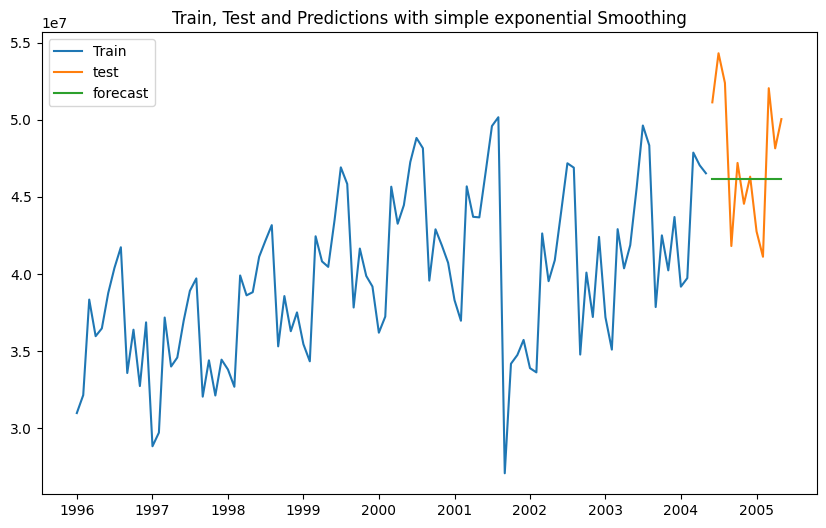

In [32]:
plt.figure(figsize=(10,6))
plt.plot(train , label='Train')
plt.plot(test , label='test')
plt.plot(predictions_simple , label='forecast')
plt.title("Train, Test and Predictions with simple exponential Smoothing")
plt.legend()
plt.show()

In [43]:
model = ExponentialSmoothing(train,trend='add',seasonal='add',seasonal_periods=12).fit()
prediction_double = model.forecast(len(test)).rename("Holt_Winters")
prediction_double

2004-06-01    4.938331e+07
2004-07-01    5.152494e+07
2004-08-01    5.110410e+07
2004-09-01    4.066947e+07
2004-10-01    4.561841e+07
2004-11-01    4.373464e+07
2004-12-01    4.562161e+07
2005-01-01    4.183479e+07
2005-02-01    4.142717e+07
2005-03-01    4.944148e+07
2005-04-01    4.722817e+07
2005-05-01    4.759574e+07
Freq: MS, Name: Holt_Winters, dtype: float64

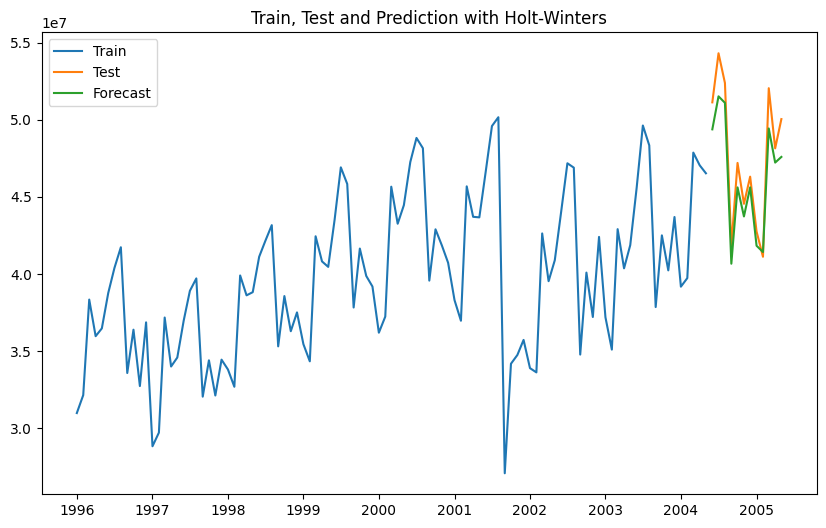

The MAE is  1441741.97
The RMSE is  1636870.88
The MAPE is 2.93 %


In [47]:
plt.figure(figsize=(10,6))
plt.plot(train, label='Train')
plt.plot(test, label="Test")
plt.plot(prediction_double, label="Forecast")
plt.legend()
plt.title("Train, Test and Prediction with Holt-Winters")
plt.show()

mae = mean_absolute_error(test,prediction_double)
mse = mean_squared_error(test,prediction_double)
rmse = np.sqrt(mse)  #convert MSE -> RMSE
mape = mean_absolute_percentage_error(test,prediction_double)
print(f"The MAE is {mae: .2f}")
print(f"The RMSE is {rmse: .2f}")
print(f"The MAPE is {100 * mape:.2f} %")

In [54]:
## Predicting the Future
model_simple = ExponentialSmoothing(df['Y'],trend='mul',seasonal='mul',seasonal_periods=12).fit()
predictions = model.forecast(len(test)).rename("Holt-Winders")
predictions

2004-06-01    4.938331e+07
2004-07-01    5.152494e+07
2004-08-01    5.110410e+07
2004-09-01    4.066947e+07
2004-10-01    4.561841e+07
2004-11-01    4.373464e+07
2004-12-01    4.562161e+07
2005-01-01    4.183479e+07
2005-02-01    4.142717e+07
2005-03-01    4.944148e+07
2005-04-01    4.722817e+07
2005-05-01    4.759574e+07
Freq: MS, Name: Holt-Winders, dtype: float64

In [65]:
# Function to plot the future
def plot_future(y, title):
  # Plot training and forecasts
  plt.figure(figsize = (10,4))
  plt.plot(train, label = 'Train')
  plt.plot(predictions, label = "Forecast")
  plt.title(f"Train and Forecast with {title}")
  plt.legend()
  plt.show()

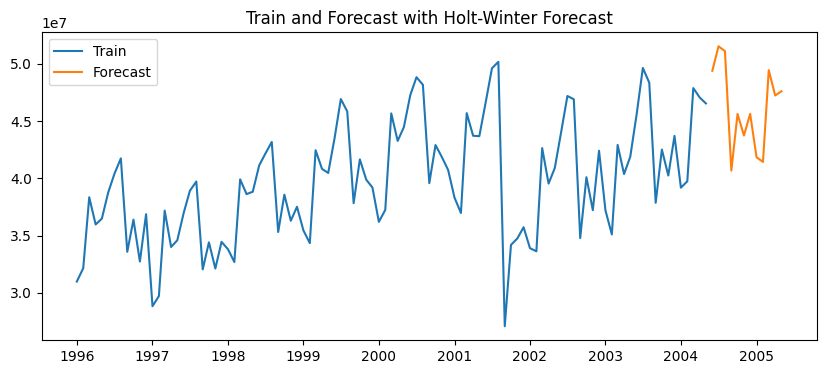

In [66]:
plot_future(df['Y'], 'Holt-Winter Forecast')

`POINTS TO REMEMBER:`

`seasonal_decompose` - To decompose a time series into its constituent parts to better understand the underlying patterns.

components

- Trend: The overall direction of the series (increasing, decreasing, or stable).
- Seasonal: Repeating patterns at fixed intervals (e.g., daily, weekly, monthly).
- Residual: The remaining variation after removing trend and seasonal components.

`Autocorrelation` measures the correlation between a time series and a lagged version of itself.

Purpose: To identify patterns or repeating cycles in a time series dataset.

Interpretation:
- Values range from -1 to 1.
- 1 indicates perfect positive correlation.
- -1 indicates perfect negative correlation.
- 0 indicates no correlation.

`ACF Plot`:
- X-axis: Lag periods
- Y-axis: Correlation coefficient

Key Features:
- At lag 0, autocorrelation is always 1 (a series is perfectly correlated with itself).
- Significant spikes at certain lags indicate repeating patterns.

`PACF` measures the correlation between a time series and its lag, after removing the effects of all shorter lags.

Purpose: To identify the direct relationship between an observation and its lag, without intermediate effects.

Main Difference between ACF and PACF:
- ACF: Measures overall correlation at each lag, including indirect effects.
- PACF: Measures direct correlation at each lag, excluding indirect effects.